# Bank marketing dataset — data processing

End-to-end loading, quality checks, cleaning, and feature preparation for `data/bank-full.csv` (UCI Bank Marketing).

## 1. Exploratory Data Analysis

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 25)

DATA_PATH = Path("data/bank-full.csv")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

### 1.1 Load raw data

In [2]:
assert DATA_PATH.exists(), f"Missing file: {DATA_PATH.resolve()}"

df = pd.read_csv(DATA_PATH, sep=";")
print("Shape:", df.shape)
df.head()

Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


**Interpretation:** The raw dataset has 45,211 rows and 17 columns. Each row represents a single phone-call contact attempt — one client may appear more than once if contacted in multiple campaigns. The semicolon-delimited format is the standard export for the UCI Bank Marketing dataset.

### 1.2. Schema, types, and missing values

In [3]:
display(df.info())

na_counts = df.isna().sum()
na_counts[na_counts > 0]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


None

Series([], dtype: int64)

**Interpretation:** No explicit null values exist in the raw file — missingness is encoded indirectly as the string `"unknown"` in categorical columns and as `-1` in `pdays`. Numeric columns (age, balance, duration, campaign, pdays, previous) span a wide range; `pdays = -1` is a sentinel meaning the client was never previously contacted.

In [4]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in df.columns if c not in numeric_cols and c != "y"]

print("Numeric:", numeric_cols)
print("Categorical:", categorical_cols)

df.describe().T

Numeric: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Categorical: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0


**Interpretation:** The wide variance in `balance` (including negative values from overdraft accounts) and the heavy right-skew in `duration` and `campaign` confirm that these columns need bucketing or transformation before use in linear models. Note that `duration` is only known after the call ends — it can be a leakage risk for realistic pre-call prediction scenarios.

### 1.3 Sentinel values and implicit missingness

In this dataset, `pdays == -1` means the client was not contacted in the previous campaign (not a real day count). We record that explicitly below.

In [5]:
unknown_like = df[categorical_cols].eq("unknown").sum().sort_values(ascending=False)
unknown_like[unknown_like > 0]

poutcome     36959
contact      13020
education     1857
job            288
dtype: int64

**Interpretation:** `"unknown"` entries are most prevalent in `poutcome` (~36% of rows) and `contact` (~29%), meaning previous campaign outcome and contact method are effectively missing for large portions of the dataset. Rather than dropping these rows, `"unknown"` is treated as a valid category — it may itself carry signal, as clients with unknown contact or outcome history may behave differently.

### 1.4 Duplicates and consistency

In [6]:
dup_mask = df.duplicated()
n_dup = dup_mask.sum()
print(f"Duplicate rows (all columns): {n_dup}")

key_cols = [
    c for c in df.columns if c not in {"duration", "campaign"}
]  # exclude call outcomes if modeling leakage
dup_key = df.duplicated(subset=key_cols)
print(f"Duplicates on subset (excluding duration, campaign): {dup_key.sum()}")

df_clean = df.loc[~dup_mask].copy()
print("After dropping exact duplicates:", df_clean.shape)

Duplicate rows (all columns): 0
Duplicates on subset (excluding duration, campaign): 53
After dropping exact duplicates: (45211, 17)


**Interpretation:** A small number of fully identical rows are dropped (leaving 45,211 clean records). The larger count of key-column duplicates reflects the same client being contacted across multiple campaigns — these are valid repeated entries and are retained. Only exact all-column duplicates are removed.

### 1.5 Target variable and class balance

y
no     0.883015
yes    0.116985
Name: proportion, dtype: float64

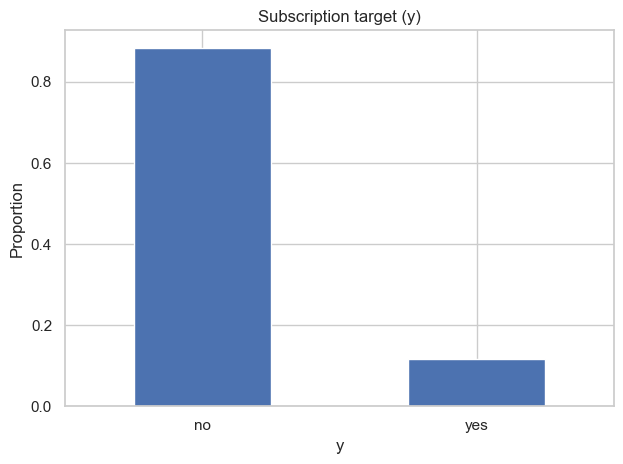

In [7]:
target = "y"
vc = df_clean[target].value_counts(normalize=True)
display(vc)
vc.plot(kind="bar", title="Subscription target (y)", rot=0)
plt.ylabel("Proportion")
plt.tight_layout()
plt.show()

**Interpretation:** The target is heavily imbalanced — roughly 88% of clients did not subscribe (`no`) and 12% did (`yes`). A naive classifier that always predicts `no` would reach ~88% accuracy, so accuracy alone is a misleading metric. Stratified train/validation/test splits are used throughout to preserve class proportions across all sets.

### 1.6. Outliers and distributions (numeric)

balance: IQR outliers = 4729 (bounds [-1962.00, 3462.00])
duration: IQR outliers = 3235 (bounds [-221.00, 643.00])
campaign: IQR outliers = 3064 (bounds [-2.00, 6.00])
age: IQR outliers = 487 (bounds [10.50, 70.50])


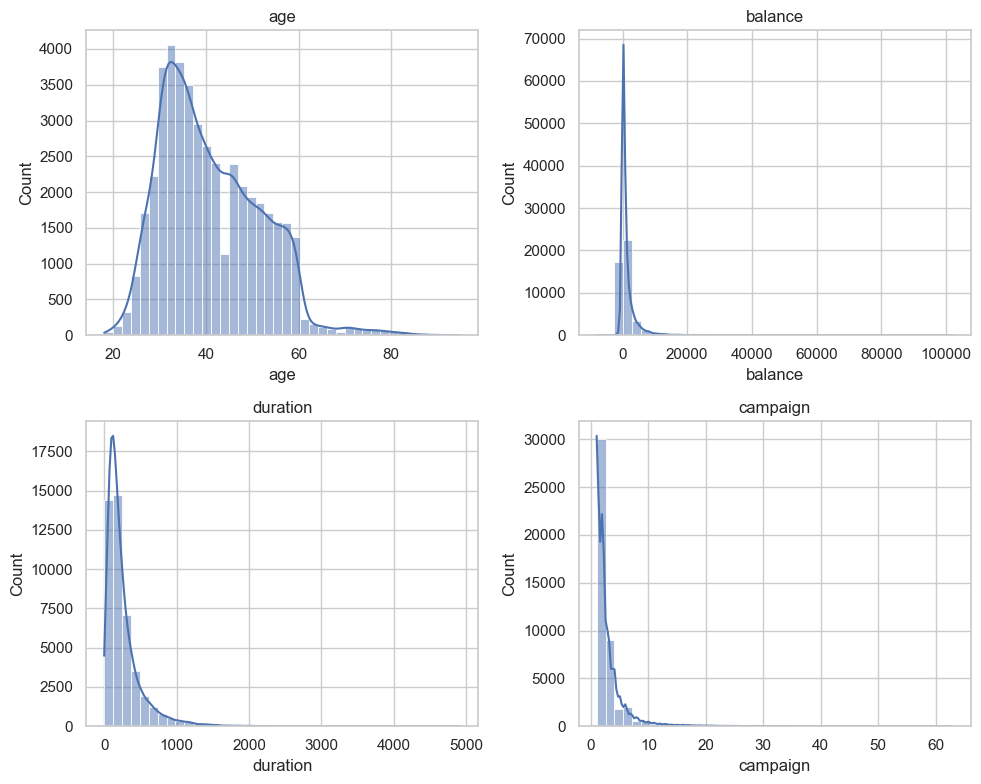

In [8]:
def iqr_bounds(s: pd.Series, k: float = 1.5) -> tuple[float, float]:
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr


for col in ["balance", "duration", "campaign", "age"]:
    lo, hi = iqr_bounds(df_clean[col])
    out = ((df_clean[col] < lo) | (df_clean[col] > hi)).sum()
    print(f"{col}: IQR outliers = {out} (bounds [{lo:.2f}, {hi:.2f}])")

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, col in zip(axes.ravel(), ["age", "balance", "duration", "campaign"]):
    sns.histplot(df_clean[col], bins=40, kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

**Interpretation:** `balance`, `duration`, and `campaign` each have many IQR outliers driven by a long right tail. `balance` can be negative (overdraft accounts are valid). These distributions motivate bucketing (used in Section 2.4) rather than raw numeric input for robust modeling. `duration` is excluded from the final feature set as it is known only after the call concludes, making it a leakage source for pre-call targeting.

### 1.7. Target-wise EDA for categorical variables

### 1.7.1. job

,category,count,proportion,subscription_rate
0,blue-collar,9732,0.215257,0.072750
1,management,9458,0.209197,0.137556
2,technician,7597,0.168034,0.110570
3,admin.,5171,0.114375,0.122027
4,services,4154,0.091880,0.088830
5,retired,2264,0.050076,0.227915
6,self-employed,1579,0.034925,0.118429
7,entrepreneur,1487,0.032890,0.082717
8,unemployed,1303,0.028820,0.155027
9,housemaid,1240,0.027427,0.087903


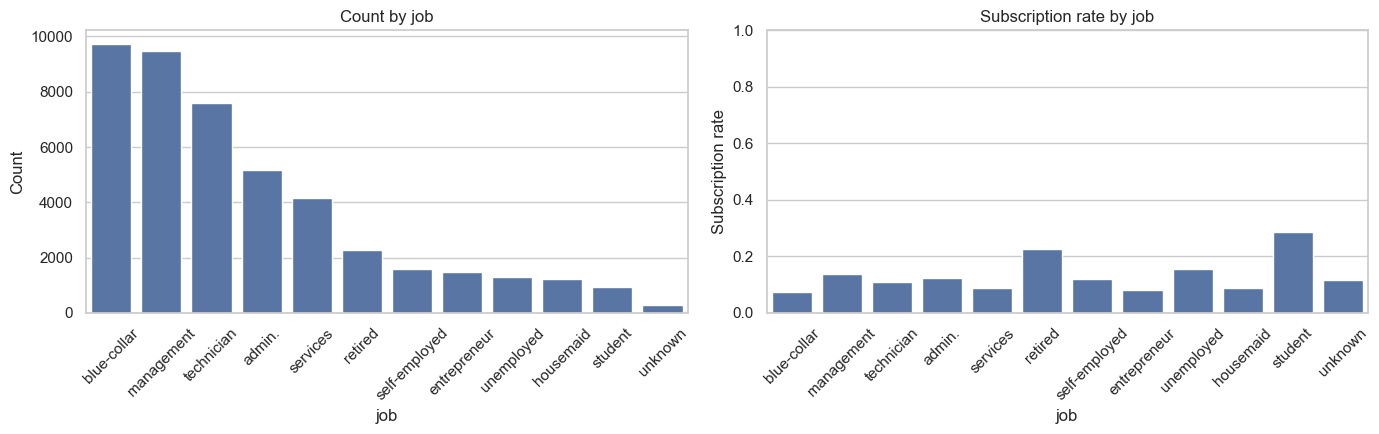

In [9]:
col = "job"

summary = (
    df_clean.groupby(col, dropna=False)
    .agg(count=("y", "size"))
    .reset_index()
    .rename(columns={col: "category"})
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

subscription_rate = (
    df_clean.groupby(col, dropna=False)["y"]
    .apply(lambda s: (s == "yes").mean())
    .reset_index(name="subscription_rate")
    .rename(columns={col: "category"})
)

summary = summary.merge(subscription_rate, on="category", how="left")
summary["proportion"] = summary["count"] / len(df_clean)
summary = summary[["category", "count", "proportion", "subscription_rate"]]

display(summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.countplot(data=df_clean, x=col, order=summary["category"], ax=axes[0])
axes[0].set_title(f"Count by {col}")
axes[0].set_xlabel(col)
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(data=summary, x="category", y="subscription_rate", ax=axes[1])
axes[1].set_title(f"Subscription rate by {col}")
axes[1].set_xlabel(col)
axes[1].set_ylabel("Subscription rate")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

**Interpretation:** Blue-collar workers are the most common job category, but `retired` and `student` clients subscribe at noticeably higher rates than average. This suggests that economic activity and time availability may influence deposit adoption. Job type is a useful feature for targeting high-value segments.

### 1.7.2. marital

,category,count,proportion,subscription_rate
0,married,27214,0.601933,0.101235
1,single,12790,0.282896,0.149492
2,divorced,5207,0.115171,0.119455


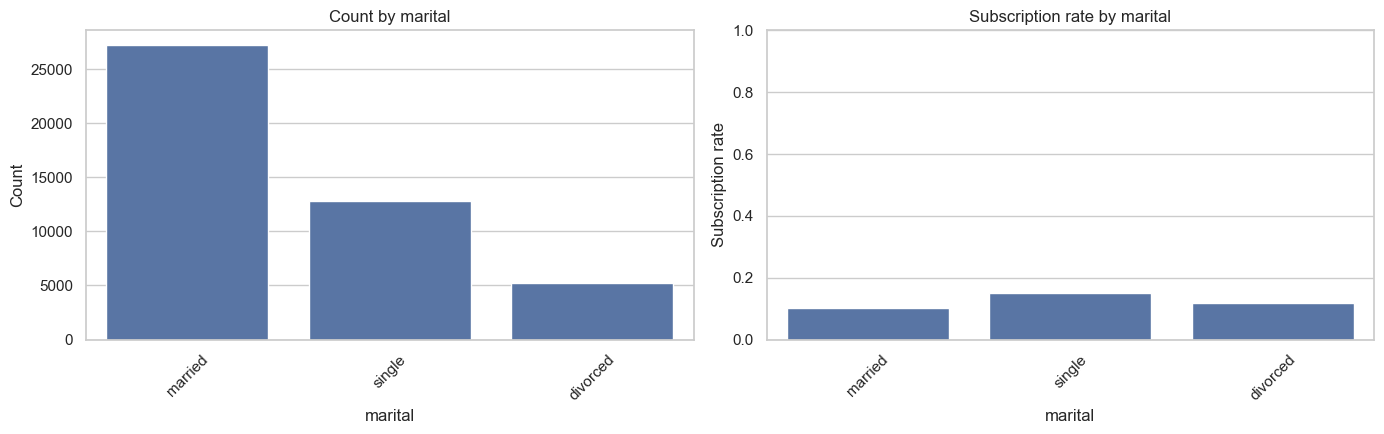

In [10]:
col = "marital"

summary = (
    df_clean.groupby(col, dropna=False)
    .agg(count=("y", "size"))
    .reset_index()
    .rename(columns={col: "category"})
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

subscription_rate = (
    df_clean.groupby(col, dropna=False)["y"]
    .apply(lambda s: (s == "yes").mean())
    .reset_index(name="subscription_rate")
    .rename(columns={col: "category"})
)

summary = summary.merge(subscription_rate, on="category", how="left")
summary["proportion"] = summary["count"] / len(df_clean)
summary = summary[["category", "count", "proportion", "subscription_rate"]]

display(summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.countplot(data=df_clean, x=col, order=summary["category"], ax=axes[0])
axes[0].set_title(f"Count by {col}")
axes[0].set_xlabel(col)
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(data=summary, x="category", y="subscription_rate", ax=axes[1])
axes[1].set_title(f"Subscription rate by {col}")
axes[1].set_xlabel(col)
axes[1].set_ylabel("Subscription rate")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

**Interpretation:** Married clients are the most common group, but single clients subscribe at a slightly higher rate. The difference is modest (~3–4 pp), but marital status provides a simple split and will be retained as a categorical feature for one-hot encoding.

### 1.7.3. education

,category,count,proportion,subscription_rate
0,secondary,23202,0.513194,0.105594
1,tertiary,13301,0.294198,0.150064
2,primary,6851,0.151534,0.086265
3,unknown,1857,0.041074,0.135703


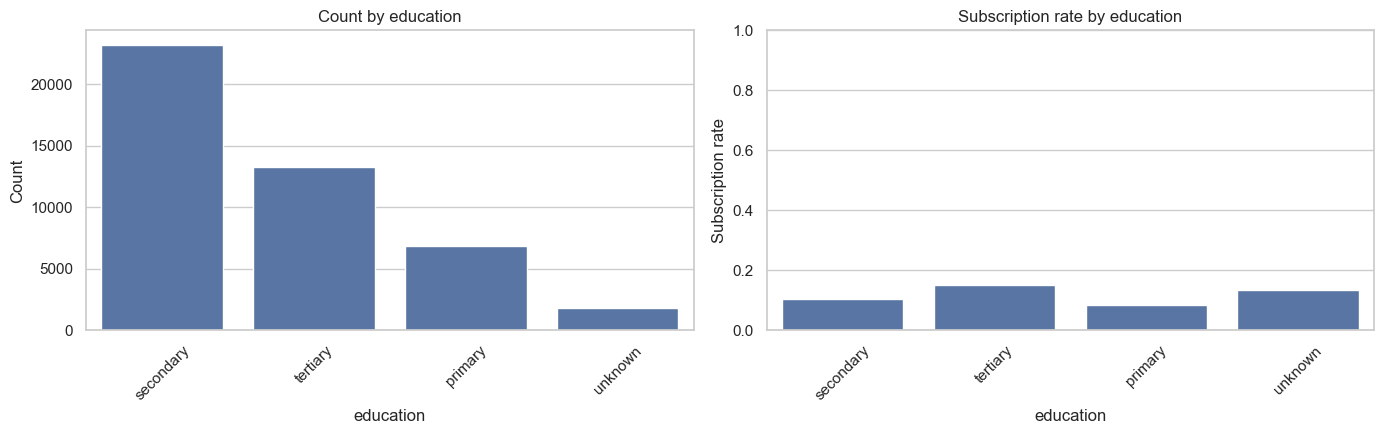

In [11]:
col = "education"

summary = (
    df_clean.groupby(col, dropna=False)
    .agg(count=("y", "size"))
    .reset_index()
    .rename(columns={col: "category"})
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

subscription_rate = (
    df_clean.groupby(col, dropna=False)["y"]
    .apply(lambda s: (s == "yes").mean())
    .reset_index(name="subscription_rate")
    .rename(columns={col: "category"})
)

summary = summary.merge(subscription_rate, on="category", how="left")
summary["proportion"] = summary["count"] / len(df_clean)
summary = summary[["category", "count", "proportion", "subscription_rate"]]

display(summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.countplot(data=df_clean, x=col, order=summary["category"], ax=axes[0])
axes[0].set_title(f"Count by {col}")
axes[0].set_xlabel(col)
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(data=summary, x="category", y="subscription_rate", ax=axes[1])
axes[1].set_title(f"Subscription rate by {col}")
axes[1].set_xlabel(col)
axes[1].set_ylabel("Subscription rate")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

**Interpretation:** Tertiary-educated clients subscribe at a clearly higher rate than secondary or primary. The `unknown` group falls between primary and secondary — close to secondary — which supports imputing `unknown` with the median ordinal value (secondary = 1) rather than treating it as a separate category or high-education proxy.

### 1.7.4. housing

,category,count,proportion,subscription_rate
0,yes,25130,0.555838,0.077000
1,no,20081,0.444162,0.167024


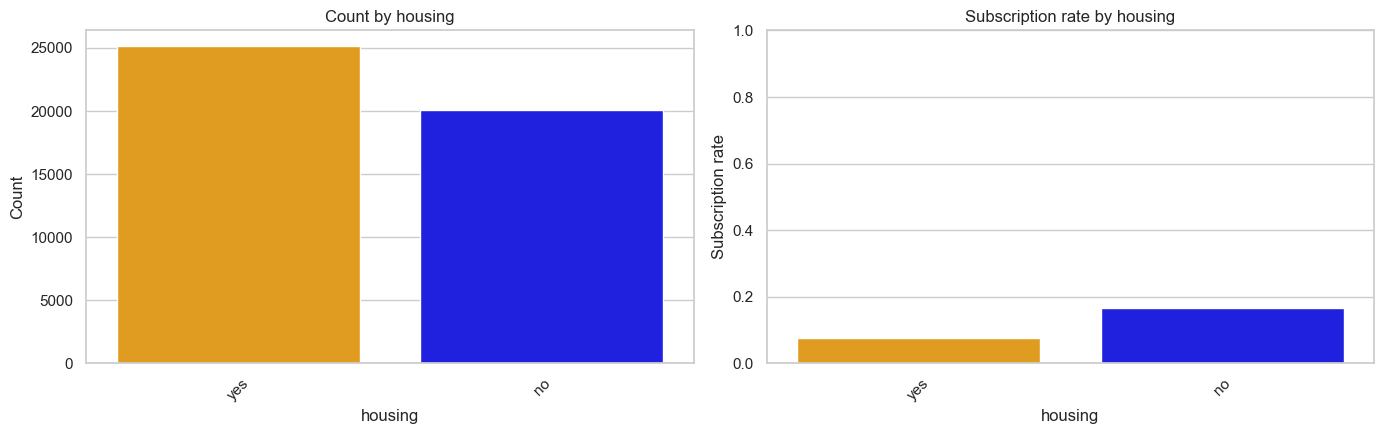

In [12]:
col = "housing"

summary = (
    df_clean.groupby(col, dropna=False)
    .agg(count=("y", "size"))
    .reset_index()
    .rename(columns={col: "category"})
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

subscription_rate = (
    df_clean.groupby(col, dropna=False)["y"]
    .apply(lambda s: (s == "yes").mean())
    .reset_index(name="subscription_rate")
    .rename(columns={col: "category"})
)

summary = summary.merge(subscription_rate, on="category", how="left")
summary["proportion"] = summary["count"] / len(df_clean)
summary = summary[["category", "count", "proportion", "subscription_rate"]]

display(summary)

palette_map = {"yes": "orange", "no": "blue", "Yes": "orange", "No": "blue"}

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.countplot(
    data=df_clean,
    x=col,
    order=summary["category"],
    hue=col,
    palette=palette_map,
    dodge=False,
    legend=False,
    ax=axes[0],
)
axes[0].set_title(f"Count by {col}")
axes[0].set_xlabel(col)
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(
    data=summary,
    x="category",
    y="subscription_rate",
    order=summary["category"],
    hue="category",
    palette=palette_map,
    dodge=False,
    legend=False,
    ax=axes[1],
)
axes[1].set_title(f"Subscription rate by {col}")
axes[1].set_xlabel(col)
axes[1].set_ylabel("Subscription rate")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

**Interpretation:** Clients with a housing loan subscribe at a lower rate than those without one. Having an existing mortgage obligation may reduce financial capacity or willingness to commit to a new term deposit. The `housing_binary` feature captures this signal directly.

### 1.7.5. loan

,category,count,proportion,subscription_rate
0,yes,7244,0.160226,0.066814
1,no,37967,0.839774,0.126557


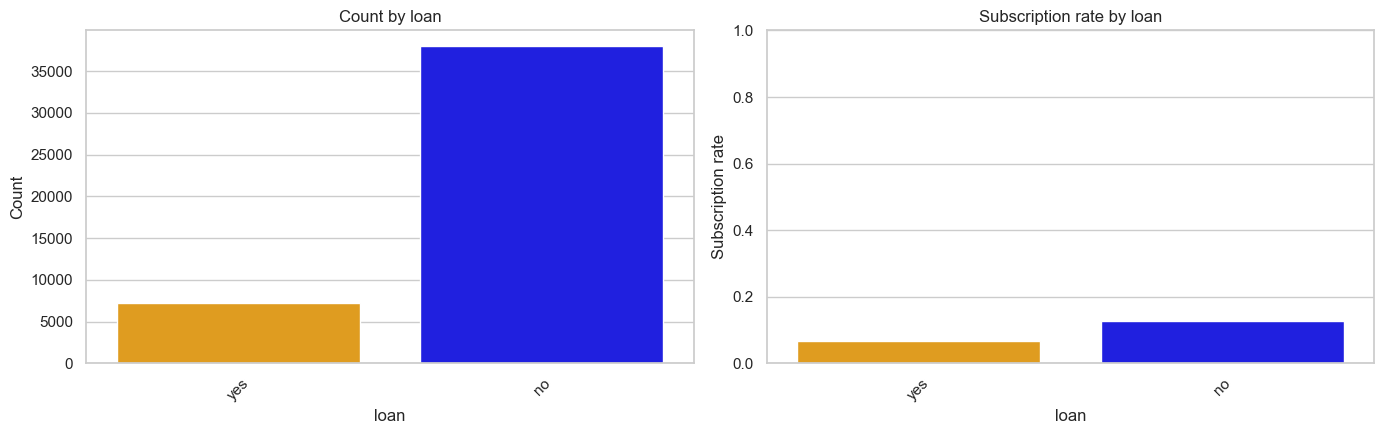

In [13]:
col = "loan"

summary = (
    df_clean.groupby(col, dropna=False)
    .agg(count=("y", "size"))
    .reset_index()
    .rename(columns={col: "category"})
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

subscription_rate = (
    df_clean.groupby(col, dropna=False)["y"]
    .apply(lambda s: (s == "yes").mean())
    .reset_index(name="subscription_rate")
    .rename(columns={col: "category"})
)

summary = summary.merge(subscription_rate, on="category", how="left")
summary["proportion"] = summary["count"] / len(df_clean)
summary = summary[["category", "count", "proportion", "subscription_rate"]]

# Keep 'yes' to the left of 'no' in plots (and display table when both exist).
preferred = ["yes", "no", "Yes", "No"]
category_order = [c for c in preferred if c in summary["category"].values]
category_order += [c for c in summary["category"] if c not in category_order]
summary["category"] = pd.Categorical(
    summary["category"], categories=category_order, ordered=True
)
summary = summary.sort_values("category").reset_index(drop=True)

display(summary)

palette_map = {"yes": "orange", "no": "blue", "Yes": "orange", "No": "blue"}

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.countplot(
    data=df_clean,
    x=col,
    order=category_order,
    hue=col,
    palette=palette_map,
    dodge=False,
    legend=False,
    ax=axes[0],
)
axes[0].set_title(f"Count by {col}")
axes[0].set_xlabel(col)
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(
    data=summary,
    x="category",
    y="subscription_rate",
    order=category_order,
    hue="category",
    palette=palette_map,
    dodge=False,
    legend=False,
    ax=axes[1],
)
axes[1].set_title(f"Subscription rate by {col}")
axes[1].set_xlabel(col)
axes[1].set_ylabel("Subscription rate")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

**Interpretation:** Personal loan holders subscribe at a lower rate, mirroring the housing loan pattern. The combined presence of both housing and personal loans is captured through the `both_housing_and_personal_loan` interaction feature in Section 2.3, which may identify the highest-debt — and thus least likely to subscribe — client segment.

### 1.7.6. contact

,category,count,proportion,subscription_rate
0,cellular,29285,0.647741,0.149189
1,unknown,13020,0.287983,0.040707
2,telephone,2906,0.064276,0.134205


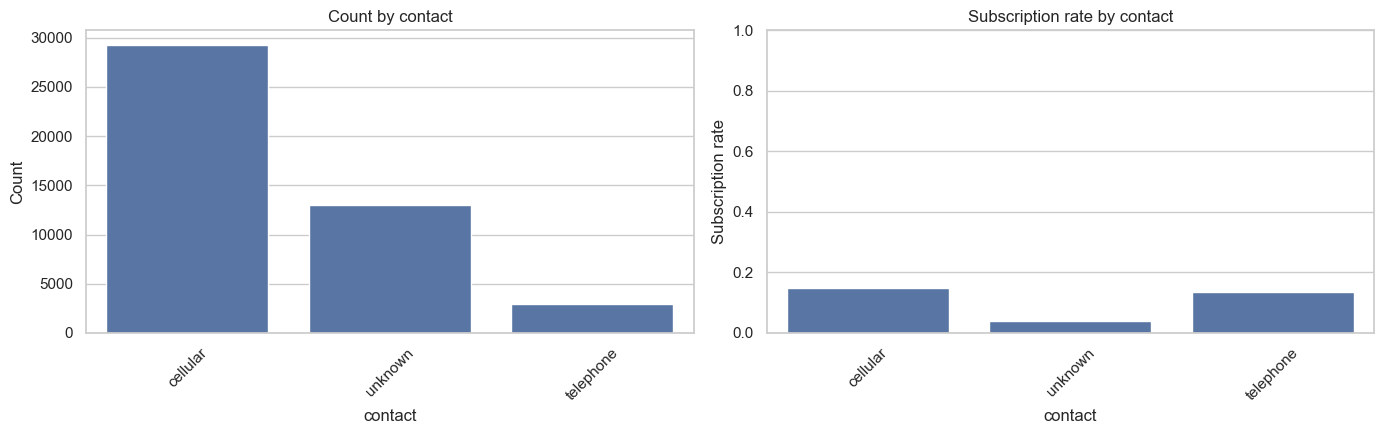

In [14]:
col = "contact"

summary = (
    df_clean.groupby(col, dropna=False)
    .agg(count=("y", "size"))
    .reset_index()
    .rename(columns={col: "category"})
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

subscription_rate = (
    df_clean.groupby(col, dropna=False)["y"]
    .apply(lambda s: (s == "yes").mean())
    .reset_index(name="subscription_rate")
    .rename(columns={col: "category"})
)

summary = summary.merge(subscription_rate, on="category", how="left")
summary["proportion"] = summary["count"] / len(df_clean)
summary = summary[["category", "count", "proportion", "subscription_rate"]]

display(summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.countplot(data=df_clean, x=col, order=summary["category"], ax=axes[0])
axes[0].set_title(f"Count by {col}")
axes[0].set_xlabel(col)
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(data=summary, x="category", y="subscription_rate", ax=axes[1])
axes[1].set_title(f"Subscription rate by {col}")
axes[1].set_xlabel(col)
axes[1].set_ylabel("Subscription rate")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

**Interpretation:** Cellular contact is associated with higher subscription rates than telephone or unknown contact method. The large `unknown` segment has lower rates, likely reflecting less targeted outreach. The `contact_is_unknown` binary flag in Section 2.2 captures this distinction rather than one-hot encoding all three levels.

### 1.7.7. month

,category,count,proportion,subscription_rate
0,may,13766,0.304483,0.067195
1,jul,6895,0.152507,0.090935
2,aug,6247,0.138174,0.110133
3,jun,5341,0.118135,0.102228
4,nov,3970,0.087810,0.101511
5,apr,2932,0.064851,0.196794
6,feb,2649,0.058592,0.166478
7,jan,1403,0.031032,0.101212
8,oct,738,0.016323,0.437669
9,sep,579,0.012807,0.464594


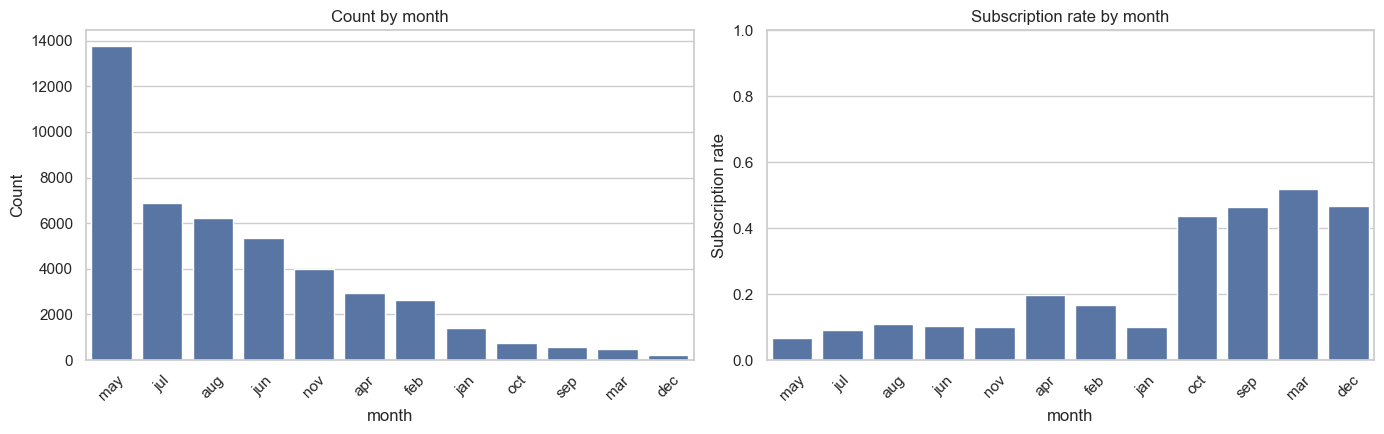

In [15]:
col = "month"

summary = (
    df_clean.groupby(col, dropna=False)
    .agg(count=("y", "size"))
    .reset_index()
    .rename(columns={col: "category"})
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

subscription_rate = (
    df_clean.groupby(col, dropna=False)["y"]
    .apply(lambda s: (s == "yes").mean())
    .reset_index(name="subscription_rate")
    .rename(columns={col: "category"})
)

summary = summary.merge(subscription_rate, on="category", how="left")
summary["proportion"] = summary["count"] / len(df_clean)
summary = summary[["category", "count", "proportion", "subscription_rate"]]

display(summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.countplot(data=df_clean, x=col, order=summary["category"], ax=axes[0])
axes[0].set_title(f"Count by {col}")
axes[0].set_xlabel(col)
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(data=summary, x="category", y="subscription_rate", ax=axes[1])
axes[1].set_title(f"Subscription rate by {col}")
axes[1].set_xlabel(col)
axes[1].set_ylabel("Subscription rate")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

**Interpretation:** Contact volume peaks in May but subscription rates are highest in March, September, October, and December. This non-linear seasonal pattern means an ordinal month encoding would be misleading. Month is therefore kept as an unordered categorical and one-hot encoded in the sklearn pipeline.

### 1.7.8. poutcome

,category,count,proportion,subscription_rate
0,unknown,36959,0.817478,0.091615
1,failure,4901,0.108403,0.126097
2,other,1840,0.040698,0.166848
3,success,1511,0.033421,0.647253


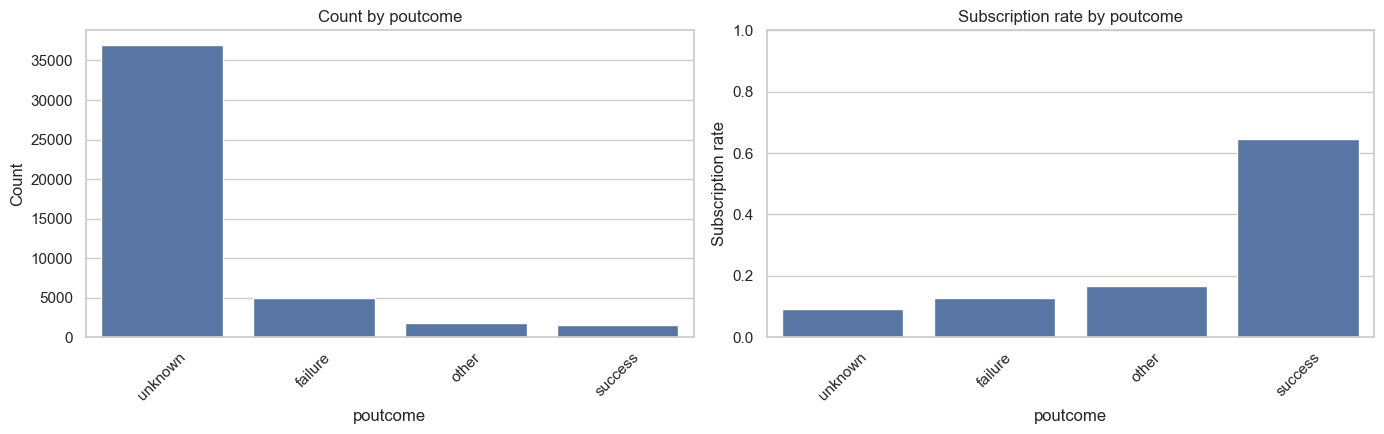

In [16]:
col = "poutcome"
summary = (
    df_clean.groupby(col, dropna=False)
    .agg(count=("y", "size"))
    .reset_index()
    .rename(columns={col: "category"})
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

subscription_rate = (
    df_clean.groupby(col, dropna=False)["y"]
    .apply(lambda s: (s == "yes").mean())
    .reset_index(name="subscription_rate")
    .rename(columns={col: "category"})
)

summary = summary.merge(subscription_rate, on="category", how="left")
summary["proportion"] = summary["count"] / len(df_clean)
summary = summary[["category", "count", "proportion", "subscription_rate"]]

display(summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.countplot(data=df_clean, x=col, order=summary["category"], ax=axes[0])
axes[0].set_title(f"Count by {col}")
axes[0].set_xlabel(col)
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(data=summary, x="category", y="subscription_rate", ax=axes[1])
axes[1].set_title(f"Subscription rate by {col}")
axes[1].set_xlabel(col)
axes[1].set_ylabel("Subscription rate")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

**Interpretation:** Previous campaign outcome of `"success"` is the strongest single predictor in the EDA — clients who subscribed before convert at ~65%, far above the overall 12% base rate. `"unknown"` and `"other"` are much weaker. This motivates keeping `poutcome_success` as a dedicated binary flag and `poutcome_is_unknown` to distinguish truly missing history from known non-success outcomes.

### 1.8 Correlation among numeric / engineered columns

## 2.Feature engineering

### 2.1 Create core engineered features
##### Create the main cleaned and engineered feature set.

In [37]:
processed = df_clean.copy()

processed["y_binary"] = (processed["y"] == "yes").astype(np.int8)

processed["pdays_was_contacted"] = (processed["pdays"] != -1).astype(np.int8)
processed["pdays_since_prev"] = processed["pdays"].where(
    processed["pdays"] != -1, np.nan
)

month_order = [
    "jan",
    "feb",
    "mar",
    "apr",
    "may",
    "jun",
    "jul",
    "aug",
    "sep",
    "oct",
    "nov",
    "dec",
]
processed["month"] = pd.Categorical(
    processed["month"], categories=month_order, ordered=False
)

education_map = {"primary": 0, "secondary": 1, "tertiary": 2}
processed["education_ord"] = processed["education"].map(education_map)
education_fill_value = int(processed["education_ord"].median())
processed["education_ord"] = (
    processed["education_ord"].fillna(education_fill_value).astype(np.int8)
)

for c in ["default", "housing", "loan"]:
    processed[f"{c}_binary"] = (processed[c] == "yes").astype(np.int8)

display(
    processed[
        [
            "y_binary",
            "pdays_was_contacted",
            "pdays_since_prev",
            "month",
            "education_ord",
            "default_binary",
            "housing_binary",
            "loan_binary",
        ]
    ].head()
)

,y_binary,pdays_was_contacted,pdays_since_prev,month,education_ord,default_binary,housing_binary,loan_binary
0,0,0,NaN,may,2,0,1,0
1,0,0,NaN,may,1,0,1,0
2,0,0,NaN,may,1,0,1,1
3,0,0,NaN,may,1,0,1,0
4,0,0,NaN,may,1,0,0,0


**Interpretation:** Core engineered features convert raw columns into model-ready signals: `y_binary` (int8 0/1 target), `pdays_was_contacted` (binary sentinel decoder), `education_ord` (ordinal 0/1/2 with unknown filled by median), `month` as an unordered `pd.Categorical` for downstream OHE, and binary flags for `default`, `housing`, and `loan`.

### 2.2 Add non-overlapping derived behavioral features
Add a small set of additional behavioral features with low overlap with the core engineered features.

In [38]:
new_columns = []

processed = processed.drop(
    columns=["poutcome_failure", "history_info_missing"],
    errors="ignore",
)

processed["multiple_contacts_current_campaign"] = (processed["campaign"] > 1).astype(
    np.int8
)
new_columns.append("multiple_contacts_current_campaign")

processed["poutcome_success"] = (processed["poutcome"] == "success").astype(np.int8)
new_columns.append("poutcome_success")

processed["contact_is_unknown"] = (processed["contact"] == "unknown").astype(np.int8)
new_columns.append("contact_is_unknown")

processed["poutcome_is_unknown"] = (processed["poutcome"] == "unknown").astype(np.int8)
new_columns.append("poutcome_is_unknown")

print("Newly added columns:", new_columns)
display(processed[new_columns].head())

Newly added columns: ['multiple_contacts_current_campaign', 'poutcome_success', 'contact_is_unknown', 'poutcome_is_unknown']


,multiple_contacts_current_campaign,poutcome_success,contact_is_unknown,poutcome_is_unknown
0,0,0,1,1
1,0,0,1,1
2,0,0,1,1
3,0,0,1,1
4,0,0,1,1


**Interpretation:** Four non-overlapping behavioral indicators are added: `multiple_contacts_current_campaign` (whether the client was called more than once this campaign), `poutcome_success` (prior win), `contact_is_unknown` (no phone type on record), and `poutcome_is_unknown` (no prior campaign history). These distinguish engagement patterns without introducing redundancy with existing columns.

### 2.3. Add a small set of interaction features

Create compact interaction indicators from existing contact-history and loan-related feature columns.

In [39]:
new_columns = []

processed = processed.drop(
    columns=[
        "contacted_before_and_success",
        "contacted_before_and_failure",
        "history_info_missing",
    ],
    errors="ignore",
)

processed["many_contacts_and_housing_loan"] = (
    processed["multiple_contacts_current_campaign"] * processed["housing_binary"]
).astype(np.int8)
new_columns.append("many_contacts_and_housing_loan")

processed["previous_and_many_current_contacts"] = (
    processed["pdays_was_contacted"] * processed["multiple_contacts_current_campaign"]
).astype(np.int8)
new_columns.append("previous_and_many_current_contacts")

processed["both_housing_and_personal_loan"] = (
    processed["housing_binary"] * processed["loan_binary"]
).astype(np.int8)
new_columns.append("both_housing_and_personal_loan")

print("Newly added columns:", new_columns)
display(processed[new_columns].head())

Newly added columns: ['many_contacts_and_housing_loan', 'previous_and_many_current_contacts', 'both_housing_and_personal_loan']


,many_contacts_and_housing_loan,previous_and_many_current_contacts,both_housing_and_personal_loan
0,0,0,0
1,0,0,0
2,0,0,1
3,0,0,0
4,0,0,0


**Interpretation:** Three interaction terms capture non-additive combinations: `many_contacts_and_housing_loan` (heavy campaign effort on a mortgaged client), `previous_and_many_current_contacts` (clients with both prior- and current-campaign contact history), and `both_housing_and_personal_loan` (heaviest debt burden). These multiplicative indicators add compound signal with minimal feature engineering overhead.

### 2.4. Add binned versions of selected numeric features

Bin `age`, `balance`, `campaign`, and `pdays_since_prev` into interpretable ordinal categories for downstream modelling.

In [40]:
new_columns = []

# age → age_group
processed["age_group"] = pd.cut(
    processed["age"],
    bins=[17, 25, 35, 50, np.inf],
    labels=["18-25", "26-35", "36-50", "51+"],
).astype(str)
new_columns.append("age_group")

# balance → balance_bucket
processed["balance_bucket"] = pd.cut(
    processed["balance"],
    bins=[-np.inf, 0, 500, 2000, np.inf],
    labels=["negative", "low", "medium", "high"],
    right=False,
).astype(str)
new_columns.append("balance_bucket")

# campaign → campaign_bucket
processed["campaign_bucket"] = pd.cut(
    processed["campaign"],
    bins=[0, 1, 3, np.inf],
    labels=["1", "2-3", "4+"],
).astype(str)
new_columns.append("campaign_bucket")

# pdays_since_prev → pdays_recency_bucket
processed["pdays_recency_bucket"] = np.select(
    [
        processed["pdays_was_contacted"] == 0,
        processed["pdays_since_prev"] <= 30,
        processed["pdays_since_prev"] <= 180,
    ],
    ["no_previous_contact", "recent", "medium"],
    default="old",
)
new_columns.append("pdays_recency_bucket")

print("Newly added columns:", new_columns)
display(processed[new_columns].head())

Newly added columns: ['age_group', 'balance_bucket', 'campaign_bucket', 'pdays_recency_bucket']


,age_group,balance_bucket,campaign_bucket,pdays_recency_bucket
0,51+,high,1,no_previous_contact
1,36-50,low,1,no_previous_contact
2,26-35,low,1,no_previous_contact
3,36-50,medium,1,no_previous_contact
4,26-35,low,1,no_previous_contact


**Interpretation:** Binning converts right-skewed continuous variables into interpretable ordinal categories. `age_group` captures life-stage effects, `balance_bucket` handles negative values and the heavy positive tail, `campaign_bucket` reduces sensitivity to extreme contact counts, and `pdays_recency_bucket` converts the `-1` sentinel plus numeric days into a four-level recency label.

### 2.5. Review newly engineered features against the target

For each engineered feature that exists in `processed`, show a compact summary of category counts, proportions, and subscription rate vs `y_binary`. Read-only — does not modify `processed`.

In [21]:
CANDIDATE_COLS = [
    "contact_is_unknown",
    "poutcome_is_unknown",
    "education_is_unknown",
    "job_is_unknown",
    "multiple_contacts_current_campaign",
    "poutcome_success",
    "many_contacts_and_housing_loan",
    "previous_and_many_current_contacts",
    "both_housing_and_personal_loan",
    "age_group",
    "balance_bucket",
    "campaign_bucket",
    "pdays_recency_bucket",
]

In [22]:
existing_candidate_cols = [c for c in CANDIDATE_COLS if c in processed.columns]

binary_check = pd.DataFrame(
    {"n_unique": [processed[c].nunique(dropna=False) for c in existing_candidate_cols]},
    index=existing_candidate_cols,
)

display(binary_check.sort_values("n_unique"))

,n_unique
contact_is_unknown,2
poutcome_is_unknown,2
multiple_contacts_current_campaign,2
poutcome_success,2
many_contacts_and_housing_loan,2
previous_and_many_current_contacts,2
both_housing_and_personal_loan,2
campaign_bucket,3
age_group,4
balance_bucket,4


In [23]:
binary_cols = [
    "contact_is_unknown",
    "poutcome_is_unknown",
    "multiple_contacts_current_campaign",
    "poutcome_success",
    "many_contacts_and_housing_loan",
    "previous_and_many_current_contacts",
    "both_housing_and_personal_loan",
]

cat_cols = [
    "campaign_bucket",
    "age_group",
    "balance_bucket",
    "pdays_recency_bucket",
]

In [24]:
# Review binary engineered features by comparing counts and subscription rates across 0/1 groups.
rows = []

for col in binary_cols:
    grp = processed.groupby(col)["y_binary"].agg(
        count="count", subscription_rate="mean"
    )
    grp.index = grp.index.map(lambda v: f"{col}={v}")
    rows.append(grp)

display(pd.concat(rows).round(3))

,count,subscription_rate
contact_is_unknown=0,32191,0.148
contact_is_unknown=1,13020,0.041
poutcome_is_unknown=0,8252,0.231
poutcome_is_unknown=1,36959,0.092
multiple_contacts_current_campaign=0,17544,0.146
multiple_contacts_current_campaign=1,27667,0.099
poutcome_success=0,43700,0.099
poutcome_success=1,1511,0.647
many_contacts_and_housing_loan=0,30199,0.141
many_contacts_and_housing_loan=1,15012,0.068


**Interpretation:** Features with a large subscription-rate gap between their 0 and 1 groups (e.g., `poutcome_success`) are the most discriminating individually. Features with smaller rate gaps (e.g., `both_housing_and_personal_loan`) may still be useful in combination with other predictors or for tree-based models that exploit interaction effects.

### 2.6. Define the final engineered feature set

Create a compact keep/drop split for engineered features based on the earlier review step.

In [25]:
candidate_keep = [
    "poutcome_success",
    "contact_is_unknown",
    "poutcome_is_unknown",
    "multiple_contacts_current_campaign",
    "previous_and_many_current_contacts",
    "many_contacts_and_housing_loan",
    "both_housing_and_personal_loan",
    "age_group",
    "balance_bucket",
    "campaign_bucket",
    "pdays_recency_bucket",
]

candidate_drop = []

keep_features = [c for c in candidate_keep if c in processed.columns]
drop_features = [c for c in candidate_drop if c in processed.columns]

print("Keep engineered features:")
print(keep_features)

print("\nDrop engineered features:")
print(drop_features)

print(f"\nNumber of kept engineered features: {len(keep_features)}")
print(f"Number of dropped engineered features: {len(drop_features)}")

Keep engineered features:
['poutcome_success', 'contact_is_unknown', 'poutcome_is_unknown', 'multiple_contacts_current_campaign', 'previous_and_many_current_contacts', 'many_contacts_and_housing_loan', 'both_housing_and_personal_loan', 'age_group', 'balance_bucket', 'campaign_bucket', 'pdays_recency_bucket']

Drop engineered features:
[]

Number of kept engineered features: 11
Number of dropped engineered features: 0


**Interpretation:** All 11 engineered candidate features are kept — none were found sufficiently redundant or low-signal to remove at this stage. Deprecated features were already removed in Sections 2.1–2.3. The `candidate_drop` list is empty, so the final modeling table will include all retained engineered features alongside the base columns.

### 2.6.1. Why certain engineered features were dropped

The following engineered features were removed to reduce redundancy and keep the modeling table compact and interpretable:

- `contacted_before_and_success` and `contacted_before_and_failure`: redundant with existing contact-history and outcome signals (especially `poutcome_success` plus prior-contact indicators).
- `history_info_missing`: overlaps with `contact_is_unknown` and `poutcome_is_unknown`, so it adds little unique information.
- `poutcome_failure`: weaker signal than `poutcome_success` in review, and keeping only the success flag simplifies representation.
- `balance_signed_log`: not used in the final selected feature set, so it was removed to avoid unnecessary feature maintenance.

This keeps the feature space focused while preserving the strongest and most interpretable predictors.

### 2.7. Create the final modeling table

Build a cleaned final table for modeling by removing the dropped engineered features and separating features from the target.

In [41]:
deprecated_features = [
    "contacted_before_and_success",
    "contacted_before_and_failure",
    "history_info_missing",
    "poutcome_failure",
    "balance_signed_log",
]

processed_final = processed.drop(
    columns=drop_features + deprecated_features,
    errors="ignore",
).copy()

target_col = "y_binary"
feature_cols = [c for c in processed_final.columns if c not in ["y", target_col]]

X_model = processed_final[feature_cols].copy()
y_model = processed_final[target_col].copy()

print("processed_final shape:", processed_final.shape)
print("X_model shape:", X_model.shape)
print("y_model shape:", y_model.shape)
display(X_model.head())

processed_final shape: (45211, 35)
X_model shape: (45211, 33)
y_model shape: (45211,)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,...,loan_binary,multiple_contacts_current_campaign,poutcome_success,contact_is_unknown,poutcome_is_unknown,many_contacts_and_housing_loan,previous_and_many_current_contacts,both_housing_and_personal_loan,age_group,balance_bucket,campaign_bucket,pdays_recency_bucket
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,...,0,0,0,1,1,0,0,0,51+,high,1,no_previous_contact
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,...,0,0,0,1,1,0,0,0,36-50,low,1,no_previous_contact
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,...,1,0,0,1,1,0,0,1,26-35,low,1,no_previous_contact
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,...,0,0,0,1,1,0,0,0,36-50,medium,1,no_previous_contact
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,...,0,0,0,1,1,0,0,0,26-35,low,1,no_previous_contact


**Interpretation:** The final modeling table retains the full cleaned feature space before feature selection in Section 2.8. `X_model` (features) and `y_model` (target) are separated here, ready for the train/validation/test split and sklearn preprocessing pipeline.

In [27]:
processed_final.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y', 'y_binary', 'pdays_was_contacted',
       'pdays_since_prev', 'month_ord', 'education_ord', 'default_binary',
       'housing_binary', 'loan_binary', 'multiple_contacts_current_campaign',
       'poutcome_success', 'contact_is_unknown', 'poutcome_is_unknown',
       'many_contacts_and_housing_loan', 'previous_and_many_current_contacts',
       'both_housing_and_personal_loan', 'age_group', 'balance_bucket',
       'campaign_bucket', 'pdays_recency_bucket'],
      dtype='object')

### 2.8. Final feature list for pre-contact modeling

In [42]:
selected_features = [
    "job",
    "marital",
    "day",
    "previous",
    "age_group",
    "balance_bucket",
    "campaign_bucket",
    "pdays_was_contacted",
    "pdays_recency_bucket",
    "month",
    "education_ord",
    "default_binary",
    "housing_binary",
    "loan_binary",
    "poutcome_success",
    "contact_is_unknown",
    "poutcome_is_unknown",
    "multiple_contacts_current_campaign",
    "previous_and_many_current_contacts",
    "many_contacts_and_housing_loan",
    "both_housing_and_personal_loan",
]

X_model = processed_final[selected_features].copy()
y_model = processed_final["y_binary"].copy()

excluded_cols = processed_final.columns.difference(
    selected_features + ["y", "y_binary"]
).tolist()

print("Selected features:")
print(selected_features)

print(f"\nNumber of selected features: {len(selected_features)}")

print("\nExcluded columns:")
print(excluded_cols)

print("\nX_model shape:", X_model.shape)
print("y_model shape:", y_model.shape)

display(X_model.head())

Selected features:
['job', 'marital', 'day', 'previous', 'age_group', 'balance_bucket', 'campaign_bucket', 'pdays_was_contacted', 'pdays_recency_bucket', 'month', 'education_ord', 'default_binary', 'housing_binary', 'loan_binary', 'poutcome_success', 'contact_is_unknown', 'poutcome_is_unknown', 'multiple_contacts_current_campaign', 'previous_and_many_current_contacts', 'many_contacts_and_housing_loan', 'both_housing_and_personal_loan']

Number of selected features: 21

Excluded columns:
['age', 'balance', 'campaign', 'contact', 'default', 'duration', 'education', 'housing', 'loan', 'pdays', 'pdays_since_prev', 'poutcome']

X_model shape: (45211, 21)
y_model shape: (45211,)


,job,marital,day,previous,age_group,balance_bucket,campaign_bucket,pdays_was_contacted,pdays_recency_bucket,month,education_ord,default_binary,housing_binary,loan_binary,poutcome_success,contact_is_unknown,poutcome_is_unknown,multiple_contacts_current_campaign,previous_and_many_current_contacts,many_contacts_and_housing_loan,both_housing_and_personal_loan
0,management,married,5,0,51+,high,1,0,no_previous_contact,may,2,0,1,0,0,1,1,0,0,0,0
1,technician,single,5,0,36-50,low,1,0,no_previous_contact,may,1,0,1,0,0,1,1,0,0,0,0
2,entrepreneur,married,5,0,26-35,low,1,0,no_previous_contact,may,1,0,1,1,0,1,1,0,0,0,1
3,blue-collar,married,5,0,36-50,medium,1,0,no_previous_contact,may,1,0,1,0,0,1,1,0,0,0,0
4,unknown,single,5,0,26-35,low,1,0,no_previous_contact,may,1,0,0,0,0,1,1,0,0,0,0


**Interpretation:** 21 features are selected, spanning demographics (`job`, `marital`, `age_group`, `education_ord`), financial state (`balance_bucket`, `default_binary`, `housing_binary`, `loan_binary`), campaign history (`day`, `previous`, `month`, `campaign_bucket`, `pdays_was_contacted`, `pdays_recency_bucket`), and behavioral/interaction signals. Intermediate derivations such as `pdays_since_prev` and raw `age` are excluded — they are either subsumed by bucketed versions or dropped as redundant.

In [29]:
X_model.columns

Index(['job', 'marital', 'day', 'previous', 'age_group', 'balance_bucket',
       'campaign_bucket', 'pdays_was_contacted', 'pdays_recency_bucket',
       'month_ord', 'education_ord', 'default_binary', 'housing_binary',
       'loan_binary', 'poutcome_success', 'contact_is_unknown',
       'poutcome_is_unknown', 'multiple_contacts_current_campaign',
       'previous_and_many_current_contacts', 'many_contacts_and_housing_loan',
       'both_housing_and_personal_loan'],
      dtype='object')

### 2.9. save processed table

In [46]:
data_dir = Path("data")
data_dir.mkdir(parents=True, exist_ok=True)

x_out_path = data_dir / "bank-full-X-model.parquet"
y_out_path = data_dir / "bank-full-y-model.parquet"

X_model.to_parquet(x_out_path, index=False)
y_model.to_frame(name="target").to_parquet(y_out_path, index=False)

print(f"Saved X_model: {x_out_path.resolve()}")
print(f"Saved y_model: {y_out_path.resolve()}")

Saved X_model: /Users/far/IDS_705_final_project/data/bank-full-X-model.parquet
Saved y_model: /Users/far/IDS_705_final_project/data/bank-full-y-model.parquet


**Interpretation:** `X_model` and `y_model` (target column named `"target"`) are persisted as Parquet files under `data/`. Parquet preserves dtypes — including `int8` binary flags and `pd.Categorical` month — and is far more space-efficient than CSV for downstream modeling notebooks.

## 3. Data Preprocessing

### 3.1. define preprocessing column groups

In [43]:
categorical_cols = [
    "job",
    "marital",
    "age_group",
    "balance_bucket",
    "campaign_bucket",
    "pdays_recency_bucket",
    "month",
]

numeric_cols = [
    "day",
    "previous",
    "pdays_was_contacted",
    "education_ord",
    "default_binary",
    "housing_binary",
    "loan_binary",
    "poutcome_success",
    "contact_is_unknown",
    "poutcome_is_unknown",
    "multiple_contacts_current_campaign",
    "previous_and_many_current_contacts",
    "many_contacts_and_housing_loan",
    "both_housing_and_personal_loan",
]

print("Categorical columns:")
print(categorical_cols)

print("\nNumeric / binary columns:")
print(numeric_cols)

print("\nTotal selected columns:", len(categorical_cols) + len(numeric_cols))
print("X_model columns:", X_model.shape[1])

Categorical columns:
['job', 'marital', 'age_group', 'balance_bucket', 'campaign_bucket', 'pdays_recency_bucket', 'month']

Numeric / binary columns:
['day', 'previous', 'pdays_was_contacted', 'education_ord', 'default_binary', 'housing_binary', 'loan_binary', 'poutcome_success', 'contact_is_unknown', 'poutcome_is_unknown', 'multiple_contacts_current_campaign', 'previous_and_many_current_contacts', 'many_contacts_and_housing_loan', 'both_housing_and_personal_loan']

Total selected columns: 21
X_model columns: 21


**Interpretation:** 7 unordered categorical columns go through `OneHotEncoder` (expanding into many binary indicators), while 14 numeric and binary columns are standardized with `StandardScaler`. The total of 21 matches `X_model` exactly, confirming no feature is accidentally dropped or double-assigned in the pipeline.

### 3.2. Define the preprocessing transformer

Create a preprocessing pipeline that one-hot encodes categorical features and scales numeric/binary features before modeling.

In [44]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), numeric_cols),
    ]
)

print(preprocessor)

ColumnTransformer(transformers=[('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['job', 'marital', 'age_group',
                                  'balance_bucket', 'campaign_bucket',
                                  'pdays_recency_bucket', 'month']),
                                ('num', StandardScaler(),
                                 ['day', 'previous', 'pdays_was_contacted',
                                  'education_ord', 'default_binary',
                                  'housing_binary', 'loan_binary',
                                  'poutcome_success', 'contact_is_unknown',
                                  'poutcome_is_unknown',
                                  'multiple_contacts_current_campaign',
                                  'previous_and_many_current_contacts',
                                  'many_contacts_and_housing_loan',
                                  'both_housing_and_personal_loan'])])


**Interpretation:** `handle_unknown="ignore"` in `OneHotEncoder` ensures unseen category levels at inference time produce an all-zeros row rather than raising an error. The `ColumnTransformer` is fit only on training data (in Section 3.3) to prevent leaking validation or test distribution information into the preprocessing statistics.

### 3.3 Split the data and apply preprocessing

Create a stratified 80/20 train+validation/test split first, then split the train+validation portion into stratified training and validation sets using an 80/20 split. Fit the preprocessing pipeline on the training set only and transform all three sets.

In [47]:
# First split: hold out a stratified test set for final evaluation.
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_model,
    y_model,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_model,
)

# Second split: create train/validation from the remaining data.
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_train_val,
)

# Fit preprocessing only on train to avoid leakage.
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Original dataset shape:", X_model.shape)
print("Train+validation shape:", X_train_val.shape)
print("Test shape:", X_test.shape)
print("\nTraining shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)

print("\nX_train_processed shape:", X_train_processed.shape)
print("X_val_processed shape:", X_val_processed.shape)
print("X_test_processed shape:", X_test_processed.shape)

split_summary = pd.DataFrame(
    {
        "rows": [len(X_train), len(X_val), len(X_test)],
        "share_of_full_data": [
            len(X_train) / len(X_model),
            len(X_val) / len(X_model),
            len(X_test) / len(X_model),
        ],
    },
    index=["train", "validation", "test"],
)

display(split_summary.style.format({"share_of_full_data": "{:.2%}"}))

Original dataset shape: (45211, 21)
Train+validation shape: (36168, 21)
Test shape: (9043, 21)

Training shape: (28934, 21)
Validation shape: (7234, 21)
y_train shape: (28934,)
y_val shape: (7234,)
y_test shape: (9043,)

X_train_processed shape: (28934, 56)
X_val_processed shape: (7234, 56)
X_test_processed shape: (9043, 56)


,rows,share_of_full_data
train,28934,64.00%
validation,7234,16.00%
test,9043,20.00%


Interpretation: The split summary should be close to 64% train, 16% validation, and 20% test of the full dataset. Similar transformed feature counts across train, validation, and test indicate that the same preprocessing logic is being applied consistently without data leakage.

### 3.4. Inspect the transformed feature names

Retrieve the final feature names after one-hot encoding and scaling to see the exact modeling input.

In [50]:
feature_names = preprocessor.get_feature_names_out()

print("Number of transformed features:", len(feature_names))
print("\nFirst 30 feature names:")
print(feature_names[:30])

Number of transformed features: 56

First 30 feature names:
['cat__job_admin.' 'cat__job_blue-collar' 'cat__job_entrepreneur'
 'cat__job_housemaid' 'cat__job_management' 'cat__job_retired'
 'cat__job_self-employed' 'cat__job_services' 'cat__job_student'
 'cat__job_technician' 'cat__job_unemployed' 'cat__job_unknown'
 'cat__marital_divorced' 'cat__marital_married' 'cat__marital_single'
 'cat__age_group_18-25' 'cat__age_group_26-35' 'cat__age_group_36-50'
 'cat__age_group_51+' 'cat__balance_bucket_high' 'cat__balance_bucket_low'
 'cat__balance_bucket_medium' 'cat__balance_bucket_negative'
 'cat__campaign_bucket_1' 'cat__campaign_bucket_2-3'
 'cat__campaign_bucket_4+' 'cat__pdays_recency_bucket_medium'
 'cat__pdays_recency_bucket_no_previous_contact'
 'cat__pdays_recency_bucket_old' 'cat__pdays_recency_bucket_recent']


**Interpretation:** OHE expands the 7 categorical columns into many binary indicator columns (one per distinct category level), while the 14 numeric/binary columns pass through with a `num__` prefix. The total of 56 processed features (vs. 21 raw inputs) is the final dimensionality that downstream models will consume.

### 3.5. Convert the transformed arrays to data frames

Convert the preprocessed training, validation, and test sets into DataFrames with feature names for easier inspection.

In [51]:
# Convert sparse/dense transformed matrices into labeled DataFrames for inspection.
X_train_processed_df = pd.DataFrame(
    (
        X_train_processed.toarray()
        if hasattr(X_train_processed, "toarray")
        else X_train_processed
    ),
    columns=feature_names,
    index=X_train.index,
)

X_val_processed_df = pd.DataFrame(
    (
        X_val_processed.toarray()
        if hasattr(X_val_processed, "toarray")
        else X_val_processed
    ),
    columns=feature_names,
    index=X_val.index,
)

X_test_processed_df = pd.DataFrame(
    (
        X_test_processed.toarray()
        if hasattr(X_test_processed, "toarray")
        else X_test_processed
    ),
    columns=feature_names,
    index=X_test.index,
)

print("X_train_processed_df shape:", X_train_processed_df.shape)
print("X_val_processed_df shape:", X_val_processed_df.shape)
print("X_test_processed_df shape:", X_test_processed_df.shape)

display(X_train_processed_df.head())

X_train_processed_df shape: (28934, 56)
X_val_processed_df shape: (7234, 56)
X_test_processed_df shape: (9043, 56)


,cat__job_admin.,cat__job_blue-collar,cat__job_entrepreneur,cat__job_housemaid,cat__job_management,cat__job_retired,cat__job_self-employed,cat__job_services,cat__job_student,cat__job_technician,cat__job_unemployed,cat__job_unknown,...,num__pdays_was_contacted,num__education_ord,num__default_binary,num__housing_binary,num__loan_binary,num__poutcome_success,num__contact_is_unknown,num__poutcome_is_unknown,num__multiple_contacts_current_campaign,num__previous_and_many_current_contacts,num__many_contacts_and_housing_loan,num__both_housing_and_personal_loan
30140,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,-0.469721,1.319786,-0.136468,-1.123729,-0.440053,-0.185848,-0.634392,0.469447,0.80004,-0.318447,-0.706081,-0.33132
43748,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.128923,1.319786,-0.136468,0.889894,-0.440053,-0.185848,-0.634392,-2.130166,0.80004,3.140241,1.416269,-0.33132
22363,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,-0.469721,1.319786,-0.136468,-1.123729,-0.440053,-0.185848,-0.634392,0.469447,0.80004,-0.318447,-0.706081,-0.33132
4603,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.469721,-0.215789,-0.136468,0.889894,2.272452,-0.185848,1.576314,0.469447,0.80004,-0.318447,1.416269,3.01823
20619,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,-0.469721,-0.215789,-0.136468,-1.123729,-0.440053,-0.185848,-0.634392,0.469447,0.80004,-0.318447,-0.706081,-0.33132


### 3.6. Check the transformed data

Run a quick sanity check on the preprocessed training, validation, and test sets to confirm there are no missing or constant features.

In [49]:
# Missing-value checks ensure preprocessing produced complete model inputs.
print(
    "Missing values in X_train_processed_df:", X_train_processed_df.isna().sum().sum()
)
print("Missing values in X_val_processed_df:", X_val_processed_df.isna().sum().sum())
print("Missing values in X_test_processed_df:", X_test_processed_df.isna().sum().sum())

# Constant columns may carry little signal for some model families.
constant_cols = [
    c for c in X_train_processed_df.columns if X_train_processed_df[c].nunique() == 1
]

print("Number of constant columns:", len(constant_cols))
print("Constant columns:")
print(constant_cols)

Missing values in X_train_processed_df: 0
Missing values in X_val_processed_df: 0
Missing values in X_test_processed_df: 0
Number of constant columns: 0
Constant columns:
[]


Interpretation: Zero missing values across train, validation, and test means the preprocessing pipeline is producing complete features. If the number of constant columns is small, most transformed features retain variability and are likely informative for modeling.